<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%207%20-%20Transformers/transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import torch
import torch.nn as nn
import numpy as np

In [30]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [31]:

# Basic Attention Block
class Attention(nn.Module):
    def __init__(self, embed_size, d_k):
        super(Attention, self).__init__()
        self.d_k = d_k
        self.embed_size = embed_size
        self.values = nn.Linear(self.embed_size, self.d_k, bias=False)
        self.keys = nn.Linear(self.embed_size, self.d_k, bias=False)
        self.query = nn.Linear(self.embed_size, self.d_k, bias=False)
    def forward(self, x, pad_mask):
        Q = self.query(x)
        V = self.values(x)
        K = self.keys(x)

        attn = (Q @ K.transpose(1,2)) / np.sqrt(self.d_k)
        pad_mask = pad_mask.unsqueeze(1)
        attn = attn.masked_fill(pad_mask, float('-inf'))
        attn = torch.softmax(attn, dim=-1)

        scores = attn @ V
        return scores

In [32]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_size, heads):
    super(MultiHeadAttention, self).__init__()
    self.embed_size = embed_size
    self.d_k = self.embed_size // heads
    self.head_attn = nn.ModuleList()
    for i in range(heads):
      self.head_attn.add_module(f'Attention Head #{i}',Attention(self.embed_size, self.d_k))

    self.linear = nn.Linear(in_features=self.embed_size, out_features=self.embed_size)
  def forward(self, x, pad_mask):
    attn_outputs = []
    for head in self.head_attn:
      attn_outputs.append(head(x, pad_mask))

    x =  torch.cat(attn_outputs, dim=-1)
    x = self.linear(x)
    return x



In [33]:
class PositionalEncoding(nn.Module):
  def __init__(self, embed_size):
    super(PositionalEncoding, self).__init__()
    self.embed_size = embed_size
  def forward(self, x):
    B, S, E = x.shape # (Batch_size, Seq, Embed)

    pos = torch.arange(S).unsqueeze(1)
    i = torch.arange(E).unsqueeze(0)

    angle_rates = pos / (10000 ** (2 * (i//2) / E))

    pe = torch.zeros(S, E).to(DEVICE)
    pe[:, 0::2] = torch.sin(angle_rates[:, 0::2])
    pe[:, 1::2] = torch.cos(angle_rates[:, 1::2])

    x = x + pe.unsqueeze(0)
    return x



In [34]:
class Encoder(nn.Module):
  def __init__(self, embed_size, heads):
    super(Encoder, self).__init__()
    self.embed_size =embed_size
    self.mult_head_attn = MultiHeadAttention(embed_size, heads=heads)
    self.norm1 = nn.LayerNorm(normalized_shape=(self.embed_size))
    self.linear1 = nn.Linear(in_features=self.embed_size, out_features= self.embed_size*4)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(in_features=self.embed_size*4, out_features= self.embed_size)
    self.norm2 = nn.LayerNorm(normalized_shape=(self.embed_size))

  def forward(self, x, pad_mask):

    shortcut = x
    x = self.mult_head_attn(x, pad_mask)
    x = x + shortcut
    x = self.norm1(x)

    shortcut = x
    x = self.linear1(x)
    x = self.relu(x)
    x = self.linear2(x)
    x = x + shortcut
    x = self.norm2(x)

    return x


In [35]:
class SentimentClassifier(nn.Module):
  def __init__(self, vocab_size=50257, embed_size=300, heads=6, num_classes=3, blocks=6):
    super(SentimentClassifier, self).__init__()
    self.embedding = nn.Embedding(num_embeddings=50257, embedding_dim=embed_size)
    self.pos_encoding = PositionalEncoding(embed_size)
    self.encoder_blocks = nn.ModuleList()
    for i in range(blocks):
      block = Encoder(embed_size=embed_size, heads=heads)
      self.encoder_blocks.add_module(f'Encoder Block #{i}', module=block)
    self.fc = nn.Linear(in_features=embed_size, out_features=num_classes)
    # self.softmax = nn.Softmax() -  CrossEntropyLoss apparently applies Softmax

  def forward(self, x): # X's Shape is (Batch_size, Seq)
    pad_mask = (x==50256) # This is for padding
    x = self.embedding(x)  # (Batch_size, Seq, Embed)
    x.shape
    x = self.pos_encoding(x)
    for block in self.encoder_blocks:
      x = block(x, pad_mask)
    x = self.fc(x)
    x = x.mean(dim=1)
    #x = self.softmax(x)
    return x




# Loading Dataset

In [66]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import load_dataset

In [37]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token

'<|endoftext|>'

In [38]:
tokenizer.encode('<|endoftext|>')

[50256]

In [86]:
ds = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset")

train_ds = ds["train"]
test_ds = ds["test"]


In [112]:
#def tokenize(batch):
    #return {
        #**tokenizer(
        #    [str(x) if x is not None else "" for x in batch["text"]],
         #   truncation=True,
        #    padding=False
       # ),
      #  "labels": batch["label"]
  #  }
#tokenized_train = train_ds.map(
  #  tokenize,
  #  batched=True,
   # remove_columns=train_ds.column_names
#)

#tokenized_test = test_ds.map(
 #   tokenize,
 #   batched=True,
 #   remove_columns=test_ds.column_names
#)

#Github can't load the output of this, so I converted everything into comments here.

In [88]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    tokenized_train,
    batch_size=50,
    shuffle=True,
    collate_fn=data_collator
)

test_loader = DataLoader(
    tokenized_test,
    batch_size=50,
    shuffle=True,
    collate_fn=data_collator
)

In [89]:
len(train_loader), len(test_loader)

(625, 105)

# Training Loop

In [91]:
import time

In [45]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.3 MB/s eta 0:00:00


In [99]:
from torchmetrics.classification import Accuracy
import matplotlib.pyplot as plt


In [100]:
model = SentimentClassifier().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=3e-4)
Accu_fn = Accuracy(task="multiclass", num_classes=3).to(DEVICE)

start = time.time()

EPOCHS = 15
train_loss_list = []
Accuracies = []
for epoch in range(EPOCHS):
  model.train()
  train_loss = 0
  for batch in train_loader:
    text = batch['input_ids'].to(DEVICE)
    label = batch['labels'].to(DEVICE)
    y_preds = model(text)
    loss = loss_fn(y_preds, label)
    optim.zero_grad()
    loss.backward()
    train_loss += loss.item()
    optim.step()
  train_loss_list.append(train_loss/len(train_loader))
  model.eval()
  accuracy = 0
  for batch in test_loader:
    text = batch['input_ids'].to(DEVICE)
    label = batch['labels'].to(DEVICE)
    with torch.inference_mode():
      y_preds = model(text)
      loss = loss_fn(y_preds, label)
      test_loss += loss.item()
      accuracy += Accu_fn(y_preds.argmax(dim=1), label)
  Accu_fn.reset()
  Accuracies.append(accuracy/len(test_loader))
  print(f"Epoch: {epoch+1} | Train Loss: {train_loss_list[-1]:.3f}  | Accuracy: {Accuracies[-1]*100:.3f}| Time: {(time.time() - start):.2f}")

finish = time.time() - start

min = finish // 60
sec = finish % 60

print(f"Training {EPOCHS} Epochs took {min} Minutes and {sec:.0f} Seconds! ")

Epoch: 1 | Train Loss: 1.039  | Accuracy: 60.883| Time: 100.87
Epoch: 2 | Train Loss: 0.827  | Accuracy: 63.873| Time: 187.99
Epoch: 3 | Train Loss: 0.720  | Accuracy: 64.013| Time: 277.15
Epoch: 4 | Train Loss: 0.615  | Accuracy: 64.260| Time: 362.60
Epoch: 5 | Train Loss: 0.506  | Accuracy: 63.663| Time: 447.85
Epoch: 6 | Train Loss: 0.401  | Accuracy: 64.152| Time: 533.27
Epoch: 7 | Train Loss: 0.309  | Accuracy: 64.089| Time: 617.81
Epoch: 8 | Train Loss: 0.245  | Accuracy: 63.187| Time: 703.15
Epoch: 9 | Train Loss: 0.188  | Accuracy: 63.435| Time: 787.85
Epoch: 10 | Train Loss: 0.168  | Accuracy: 62.419| Time: 872.17
Epoch: 11 | Train Loss: 0.143  | Accuracy: 62.260| Time: 956.84
Epoch: 12 | Train Loss: 0.120  | Accuracy: 63.346| Time: 1042.46
Epoch: 13 | Train Loss: 0.104  | Accuracy: 62.527| Time: 1127.25
Epoch: 14 | Train Loss: 0.101  | Accuracy: 63.568| Time: 1212.23
Epoch: 15 | Train Loss: 0.089  | Accuracy: 64.356| Time: 1296.56
Training 15 Epochs took 21.0 Minutes and 37 S

In [105]:
Accuracies = [x.item() for x in Accuracies]

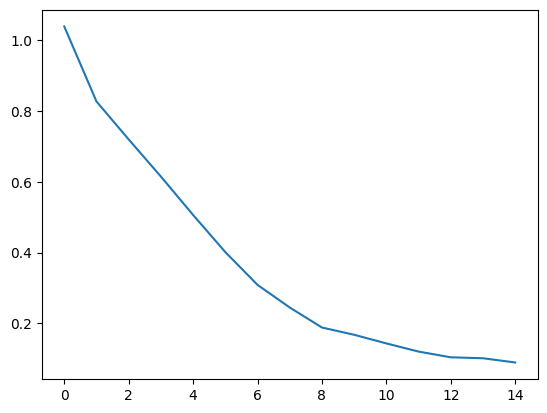

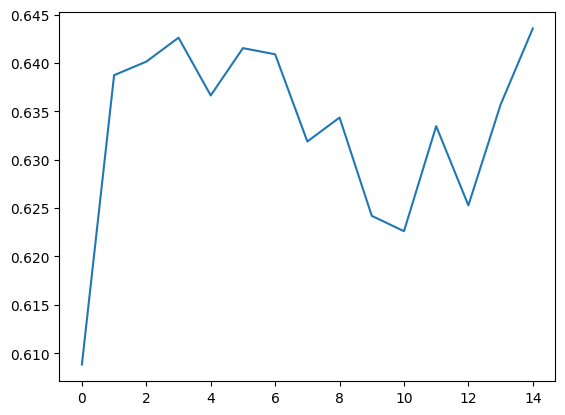

In [106]:
plt.plot(train_loss_list)
plt.show()
plt.plot(Accuracies)
plt.show()

In [107]:
def Sentiment(text):
  cat = ['negative', 'neutral', 'positive']
  tokens = torch.tensor(tokenizer.encode(text)).unsqueeze(0).to(DEVICE)
  prediction = nn.Softmax()(model(tokens)).argmax()
  print(cat[prediction.item()])

In [108]:
Sentiment("I am Happy with this!")

positive


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [109]:
Sentiment("I HATE THIS!!!!")

negative


In [110]:
Sentiment("I just love debugging so much"), Sentiment("I just LOVE debugging so much")

# Seems to recognize sarcasm on some level

positive
neutral


(None, None)

In [111]:
Sentiment("Anyone know when the next update is?")

neutral
